In [2]:
from Bio import SeqIO
import io
import requests

# Biological Database (UniProt) IDs for Serotonin 5-HT2A Receptor
species_ids = {"Human": "P28223", "Mouse": "P35363", "Zebrafish": "Q98894"}

sequences = {}

print("Fetching receptor sequences from UniProt...\n")

# Browser like header so that UniProt server dont block it
headers = {"User-Agent": "Mozilla/5.0"}

for species, uniprot_id in species_ids.items():
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"

    # downloading the data
    response = requests.get(url, headers=headers)

    if response.status_code == 200:
        # File reading directly from the memory without saving it locally
        fasta_io = io.StringIO(response.text)
        record = SeqIO.read(fasta_io, "fasta")

        sequences[species] = record.seq
        print(
            f"✅ {species} Receptor Length: {len(record.seq)} amino acids"
        )
    else:
        print(f"❌ Error fetching {species}: Status code {response.status_code}")

print("\nAll sequences process complete!")

Fetching receptor sequences from UniProt...

✅ Human Receptor Length: 471 amino acids
✅ Mouse Receptor Length: 471 amino acids
✅ Zebrafish Receptor Length: 468 amino acids

All sequences process complete!


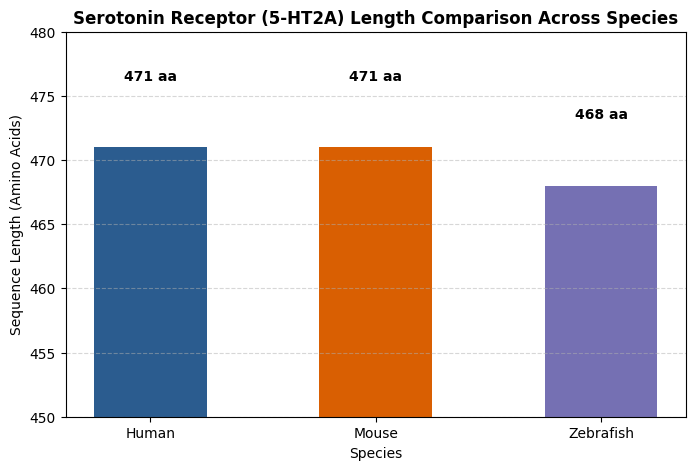

In [3]:
import matplotlib.pyplot as plt

# preparing the data
species_names = list(sequences.keys())
lengths = [len(seq) for seq in sequences.values()]

# desgining the graph
plt.figure(figsize=(8, 5))
bars = plt.bar(species_names, lengths, color=['#2b5c8f', '#d95f02', '#7570b3'], width=0.5)

# for writing the exact values above the graph
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, f"{yval} aa", ha='center', va='bottom', fontweight='bold')

# Labels aur Title
plt.title('Serotonin Receptor (5-HT2A) Length Comparison Across Species', fontsize=12, fontweight='bold')
plt.xlabel('Species', fontsize=10)
plt.ylabel('Sequence Length (Amino Acids)', fontsize=10)
plt.ylim(450, 480) # Y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Display chart
plt.show()

In [ ]:
# Human and Mouse sequence comparing
human_seq = sequences['Human']
mouse_seq = sequences['Mouse']

# Total matching amino acids count 
matches = 0
total = len(human_seq)

for i in range(total):
    if human_seq[i] == mouse_seq[i]:
        matches += 1

identity_percentage = (matches / total) * 100

print(f"--- HUMAN vs MOUSE RECEPTOR COMPARISON ---")
print(f"Total Amino Acids   : {total}")
print(f"Exact Matches       : {matches}")
print(f"Sequence Similarity : {identity_percentage:.2f}%")

--- HUMAN vs MOUSE RECEPTOR COMPARISON ---
Total Amino Acids   : 471
Exact Matches       : 431
Sequence Similarity : 91.51%
